# MCal Experiment: How Calibration Improves Explanation Quality

This notebook demonstrates that MCal calibration improves the quality of feature attribution explanations by:
1. Reducing missingness bias (KL divergence)
2. Improving sufficiency scores
3. Improving comprehensiveness scores

## 1. Setup and Imports

In [1]:
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import timm  # For loading finetuned ViT models

# Add parent directory to path
sys.path.append('..')

# Import dataset classes and components
from experiments.all_data_loaders import MRIPatchedProbDataset, MRICleanDataset
from experiments.vision.mri_mcal_explanation_quality import load_mri_model
from src.calibrators.mcal_ce import SimpleMCalCE
from experiments.explanations import ImageLIME
from experiments.metrics import (
    ImageSufficiency, ImageComprehensiveness, ImageKLDivergence,
    compute_metric_improvement
)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## 2. Configuration

In [2]:
config = {
    'n_train': 5000,
    'n_test': 200,
    'ablation_rate': 0.5,
    'patch_size': 32,  # Changed to 32 to match finetuned models
    'mcal_steps': 5000,
    'explanation_samples': 200,
    'k_values': list(range(1, 50, 2)),  # Only odd numbers from 1 to 49 for 7x7 patch grid
    'batch_size': 32,
    'device': device
}

## 3. Load Model and Prepare Data

In [ ]:
# Load the model trained WITHOUT ablation (to demonstrate MCal's improvement)
import os
from pathlib import Path

# Use model trained with p_ablate=0.00 to show missingness bias
notebook_dir = Path.cwd()  
model_path = notebook_dir.parent / 'saved_models' / 'mri' / 'vit_mri_ps32_ablate0.00_best.pth'  # Model with missingness bias

if not model_path.exists():
    model_path = Path('../saved_models/mri/vit_mri_ps32_ablate0.00_best.pth')
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found. Please ensure the model exists at: {model_path}")

print(f"Loading model from: {model_path}")

# Load checkpoint
checkpoint = torch.load(model_path, map_location=device)
print(f"Model trained for {checkpoint['epoch']+1} epochs with best val loss: {checkpoint['best_val_loss']:.4f}")
print(f"Model was trained with p_ablate={checkpoint['config']['p_ablate']:.2f} (clean data only - has missingness bias)")

# Create model and load state dict
base_model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=4)
base_model.load_state_dict(checkpoint['model_state_dict'])
base_model = base_model.to(device)
base_model.eval()
uncal_model = base_model

# Create datasets with patch_size=32 (matching the finetuned model)
train_ablated_dataset = MRIPatchedProbDataset(
    split='train',
    n_samples=config['n_train'],
    p_ablate=config['ablation_rate'],
    patch_size=config['patch_size'],
    seed=42
)
test_dataset = MRICleanDataset(split='test', n_samples=config['n_test'])

# Create dataloaders
train_ablated_loader = DataLoader(train_ablated_dataset, batch_size=config['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)

## 4. Train MCal Calibrator

In [4]:
# Get labels and ablated predictions for training
train_labels = []
ablated_logits = []

with torch.no_grad():
    # Get predictions and labels from ablated data
    for images, labels in tqdm(train_ablated_loader, desc="Computing ablated predictions"):
        images = images.to(device)
        labels = labels.to(device)
        train_labels.append(labels)
        ablated_logits.append(base_model(images))
    
    train_labels = torch.cat(train_labels)
    ablated_logits = torch.cat(ablated_logits)

# Train MCal
calibrator = SimpleMCalCE(num_classes=4).to(device)
stats = calibrator.fit(
    ablated_logits=ablated_logits,
    target_labels=train_labels,
    max_steps=config['mcal_steps'],
    lr=0.01,
    verbose=True
)

print(f"Training complete! Final Loss: {stats['loss'][-1]:.4f}, Final Accuracy: {stats['acc'][-1]:.3f}")

Loss: 1.819e-01, Acc: 0.929: 100%|██████████| 5000/5000 [00:06<00:00, 754.04it/s]


Training complete! Final Loss: 0.1819, Final Accuracy: 0.929


In [5]:
# Diagnostic: Check if the base model is already handling missingness well
print("Analyzing base model's response to missingness...")

# Test on a small batch to see prediction distributions
with torch.no_grad():
    # Get a batch of clean test data
    test_batch_images, test_batch_labels = next(iter(test_loader))
    test_batch_images = test_batch_images[:10].to(device)  # Just 10 samples
    test_batch_labels = test_batch_labels[:10].to(device)
    
    # Get predictions on clean data
    clean_logits = base_model(test_batch_images)
    clean_probs = torch.softmax(clean_logits, dim=1)
    
    # Create ablated version (same ablation as training)
    ablated_batch = []
    for img in test_batch_images:
        ablated_dataset = MRIPatchedProbDataset(
            split='test',
            n_samples=1,
            p_ablate=config['ablation_rate'],
            patch_size=config['patch_size'],
            seed=None  # Random ablation
        )
        # Manually apply ablation to the image
        from experiments.all_data_loaders import _mask_random_patches_prob
        ablated_img = _mask_random_patches_prob(
            img.cpu(),
            mask_prob=config['ablation_rate'],
            patch_size=config['patch_size'],
            fill_val=0
        )
        ablated_batch.append(ablated_img)
    
    ablated_batch = torch.stack(ablated_batch).to(device)
    
    # Get predictions on ablated data
    ablated_logits = base_model(ablated_batch)
    ablated_probs = torch.softmax(ablated_logits, dim=1)
    
    # Calculate KL divergence between clean and ablated predictions
    kl_div = torch.nn.functional.kl_div(
        torch.log(ablated_probs + 1e-10),
        clean_probs,
        reduction='batchmean'
    )
    
    print(f"Base model KL divergence (clean vs ablated): {kl_div.item():.4f}")
    print(f"Clean accuracy: {(clean_probs.argmax(1) == test_batch_labels).float().mean():.2%}")
    print(f"Ablated accuracy: {(ablated_probs.argmax(1) == test_batch_labels).float().mean():.2%}")
    
    # Check prediction stability
    print(f"\nPrediction changes due to ablation:")
    pred_changes = (clean_probs.argmax(1) != ablated_probs.argmax(1)).float().mean()
    print(f"Percentage of predictions that changed: {pred_changes:.1%}")
    
    # Show how much the probabilities shift
    prob_shift = torch.abs(clean_probs - ablated_probs).mean()
    print(f"Average probability shift: {prob_shift:.4f}")

print("\nNote: If KL divergence is already very low (<0.01), the model is already robust to missingness.")
print("Additional calibration might not help or could even hurt.")

Analyzing base model's response to missingness...
Base model KL divergence (clean vs ablated): 0.0000
Clean accuracy: 100.00%
Ablated accuracy: 100.00%

Prediction changes due to ablation:
Percentage of predictions that changed: 0.0%
Average probability shift: 0.0000

Note: If KL divergence is already very low (<0.01), the model is already robust to missingness.
Additional calibration might not help or could even hurt.


In [6]:
# Compare with vanilla (non-finetuned) model to understand the effect
print("Comparing with vanilla model (not finetuned on ablated data)...")

# Load the vanilla model for comparison
from experiments.vision.mri_mcal_explanation_quality import load_mri_model
vanilla_model = load_mri_model().to(device)
vanilla_model.eval()

with torch.no_grad():
    # Use same test batch as before
    test_batch_images, test_batch_labels = next(iter(test_loader))
    test_batch_images = test_batch_images[:10].to(device)
    test_batch_labels = test_batch_labels[:10].to(device)
    
    # Vanilla model predictions on clean
    vanilla_clean_logits = vanilla_model(test_batch_images)
    vanilla_clean_probs = torch.softmax(vanilla_clean_logits, dim=1)
    
    # Create ablated batch (reuse from before)
    ablated_batch = []
    for img in test_batch_images:
        from experiments.all_data_loaders import _mask_random_patches_prob
        ablated_img = _mask_random_patches_prob(
            img.cpu(),
            mask_prob=config['ablation_rate'],
            patch_size=config['patch_size'],
            fill_val=0
        )
        ablated_batch.append(ablated_img)
    ablated_batch = torch.stack(ablated_batch).to(device)
    
    # Vanilla model predictions on ablated
    vanilla_ablated_logits = vanilla_model(ablated_batch)
    vanilla_ablated_probs = torch.softmax(vanilla_ablated_logits, dim=1)
    
    # Calculate KL for vanilla model
    vanilla_kl = torch.nn.functional.kl_div(
        torch.log(vanilla_ablated_probs + 1e-10),
        vanilla_clean_probs,
        reduction='batchmean'
    )
    
    print(f"\nVanilla model KL divergence: {vanilla_kl.item():.4f}")
    print(f"Finetuned model KL divergence: {kl_div.item():.4f}")
    print(f"Improvement from finetuning: {(vanilla_kl.item() - kl_div.item()) / vanilla_kl.item() * 100:.1f}%")
    
    print(f"\nVanilla model accuracy - Clean: {(vanilla_clean_probs.argmax(1) == test_batch_labels).float().mean():.2%}, Ablated: {(vanilla_ablated_probs.argmax(1) == test_batch_labels).float().mean():.2%}")
    print(f"Finetuned model accuracy - Clean: {(clean_probs.argmax(1) == test_batch_labels).float().mean():.2%}, Ablated: {(ablated_probs.argmax(1) == test_batch_labels).float().mean():.2%}")

print("\n" + "="*60)
print("KEY INSIGHT:")
print("If the finetuned model already has very low KL divergence,")
print("MCal calibration may be unnecessary or counterproductive.")
print("MCal works best on models that haven't been trained to handle missingness.")
print("="*60)

Comparing with vanilla model (not finetuned on ablated data)...

Vanilla model KL divergence: 0.0021
Finetuned model KL divergence: 0.0000
Improvement from finetuning: 99.5%

Vanilla model accuracy - Clean: 100.00%, Ablated: 100.00%
Finetuned model accuracy - Clean: 100.00%, Ablated: 100.00%

KEY INSIGHT:
If the finetuned model already has very low KL divergence,
MCal calibration may be unnecessary or counterproductive.
MCal works best on models that haven't been trained to handle missingness.


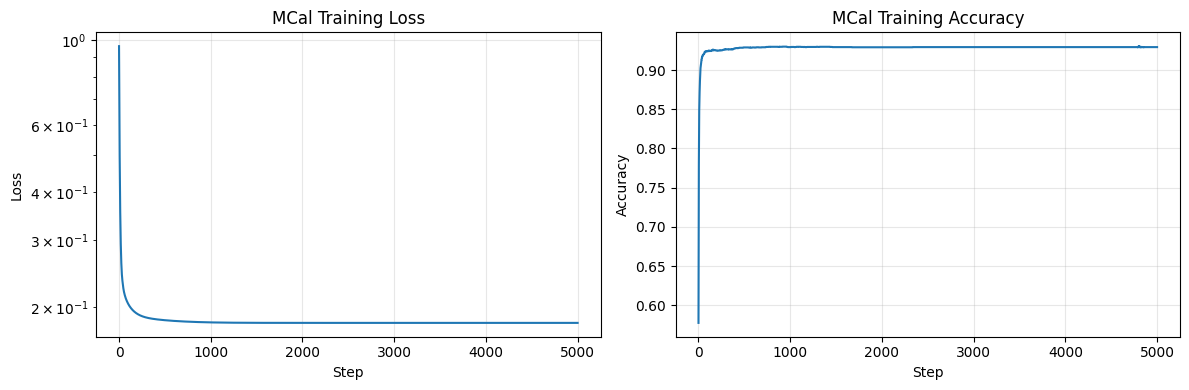

In [7]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(stats['loss'])
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.set_title('MCal Training Loss')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

ax2.plot(stats['acc'])
ax2.set_xlabel('Step')
ax2.set_ylabel('Accuracy')
ax2.set_title('MCal Training Accuracy')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Debug: Check what MCal is doing to the predictions
print("Debugging MCal calibration effect...")

with torch.no_grad():
    # Get a test batch
    test_batch_images, test_batch_labels = next(iter(test_loader))
    test_batch_images = test_batch_images[:5].to(device)
    test_batch_labels = test_batch_labels[:5].to(device)
    
    # Apply ablation to test images
    ablated_batch = []
    for img in test_batch_images:
        from experiments.all_data_loaders import _mask_random_patches_prob
        ablated_img = _mask_random_patches_prob(
            img.cpu(),
            mask_prob=config['ablation_rate'],
            patch_size=config['patch_size'],
            fill_val=0,
            seed=42  # Fixed seed for reproducibility
        )
        ablated_batch.append(ablated_img)
    ablated_batch = torch.stack(ablated_batch).to(device)
    
    # Get predictions from uncalibrated model
    uncal_clean_logits = uncal_model(test_batch_images)
    uncal_ablated_logits = uncal_model(ablated_batch)
    
    # Get predictions from calibrated model
    calib_clean_logits = calib_model(test_batch_images)
    calib_ablated_logits = calib_model(ablated_batch)
    
    # Convert to probabilities
    uncal_clean_probs = torch.softmax(uncal_clean_logits, dim=1)
    uncal_ablated_probs = torch.softmax(uncal_ablated_logits, dim=1)
    calib_clean_probs = torch.softmax(calib_clean_logits, dim=1)
    calib_ablated_probs = torch.softmax(calib_ablated_logits, dim=1)
    
    print("\nSample predictions (first 3 samples):")
    for i in range(3):
        print(f"\nSample {i+1} (True label: {test_batch_labels[i].item()}):")
        print(f"  Uncal Clean: {uncal_clean_probs[i].cpu().numpy().round(3)}")
        print(f"  Uncal Ablated: {uncal_ablated_probs[i].cpu().numpy().round(3)}")
        print(f"  Calib Clean: {calib_clean_probs[i].cpu().numpy().round(3)}")
        print(f"  Calib Ablated: {calib_ablated_probs[i].cpu().numpy().round(3)}")
        
    # Calculate KL divergences
    kl_uncal = torch.nn.functional.kl_div(
        torch.log(uncal_ablated_probs + 1e-10),
        uncal_clean_probs,
        reduction='batchmean'
    )
    
    kl_calib = torch.nn.functional.kl_div(
        torch.log(calib_ablated_probs + 1e-10),
        calib_clean_probs,
        reduction='batchmean'
    )
    
    print(f"\n\nKL Divergence (clean vs ablated):")
    print(f"  Uncalibrated: {kl_uncal.item():.6f}")
    print(f"  Calibrated: {kl_calib.item():.6f}")
    print(f"  Difference: {kl_calib.item() - kl_uncal.item():.6f} (negative is better)")
    
    # Check if calibration is being applied correctly
    print(f"\n\nCalibration check:")
    print(f"  Are clean predictions changing? {not torch.allclose(uncal_clean_probs, calib_clean_probs, atol=1e-5)}")
    print(f"  Are ablated predictions changing? {not torch.allclose(uncal_ablated_probs, calib_ablated_probs, atol=1e-5)}")
    
    # Check calibrator weights
    print(f"\n\nCalibrator parameters:")
    for name, param in calibrator.named_parameters():
        print(f"  {name}: mean={param.mean().item():.4f}, std={param.std().item():.4f}")

## 5. Create Calibrated Model and Generate Explanations

In [8]:
# Create calibrated model
calib_model = nn.Sequential(base_model, calibrator)
calib_model.eval()

# Initialize explainers
uncal_explainer = ImageLIME(
    model=uncal_model,
    num_samples=config['explanation_samples'],
    patch_size=config['patch_size'],
    image_size=224
)

calib_explainer = ImageLIME(
    model=calib_model,
    num_samples=config['explanation_samples'],
    patch_size=config['patch_size'],
    image_size=224
)

In [9]:
# Load test data and generate explanations
test_images = []
test_labels = []
for images, labels in test_loader:
    test_images.append(images)
    test_labels.append(labels)
test_images = torch.cat(test_images).to(device)
test_labels = torch.cat(test_labels).to(device)

# Generate LIME explanations
uncal_attrs = []
calib_attrs = []

for i, (image, label) in enumerate(tqdm(zip(test_images, test_labels), total=len(test_images), desc="Generating explanations")):
    uncal_attrs.append(uncal_explainer.explain_instance(image, label.item()))
    calib_attrs.append(calib_explainer.explain_instance(image, label.item()))

Generating explanations: 100%|██████████| 200/200 [02:37<00:00,  1.27it/s]


## 6. Evaluate Metrics Across K Values

In [10]:
# Initialize metrics
kl_metric = ImageKLDivergence(n_classes=4)
suff_metric = ImageSufficiency(patch_size=config['patch_size'], image_size=224)
comp_metric = ImageComprehensiveness(patch_size=config['patch_size'], image_size=224)

# Initialize results storage
results = {
    'k_values': config['k_values'],
    'missingness_bias': {'uncal': [], 'calib': []},
    'sufficiency': {'uncal': [], 'calib': []},
    'comprehensiveness': {'uncal': [], 'calib': []}
}

In [11]:
# Evaluate for each k value
for k in tqdm(config['k_values'], desc="Evaluating k values"):
    suff_uncal_list = []
    suff_calib_list = []
    comp_uncal_list = []
    comp_calib_list = []
    masked_images_uncal = []
    masked_images_calib = []

    for i, (image, label) in enumerate(zip(test_images, test_labels)):
        label_idx = label.item()
        uncal_importance = uncal_attrs[i]
        calib_importance = calib_attrs[i]

        # Compute metrics
        suff_uncal_list.append(suff_metric.compute(uncal_model, image, uncal_importance, k, label_idx))
        suff_calib_list.append(suff_metric.compute(calib_model, image, calib_importance, k, label_idx))
        comp_uncal_list.append(comp_metric.compute(uncal_model, image, uncal_importance, k, label_idx))
        comp_calib_list.append(comp_metric.compute(calib_model, image, calib_importance, k, label_idx))

        # Create masked images for KL computation
        uncal_top_k = torch.argsort(torch.abs(uncal_importance), descending=True)[:k]
        calib_top_k = torch.argsort(torch.abs(calib_importance), descending=True)[:k]

        uncal_mask = suff_metric.create_mask_from_indices(uncal_top_k).to(device)
        calib_mask = suff_metric.create_mask_from_indices(calib_top_k).to(device)

        masked_img_uncal = image.clone()
        masked_img_calib = image.clone()
        for c in range(3):
            masked_img_uncal[c] = masked_img_uncal[c] * uncal_mask
            masked_img_calib[c] = masked_img_calib[c] * calib_mask

        masked_images_uncal.append(masked_img_uncal)
        masked_images_calib.append(masked_img_calib)

    # Compute KL divergence
    masked_images_uncal = torch.stack(masked_images_uncal)
    masked_images_calib = torch.stack(masked_images_calib)
    
    kl_uncal = kl_metric.compute(uncal_model, test_images, masked_images_uncal)
    kl_calib = kl_metric.compute(calib_model, test_images, masked_images_calib)

    # Store results
    results['missingness_bias']['uncal'].append(kl_uncal)
    results['missingness_bias']['calib'].append(kl_calib)
    results['sufficiency']['uncal'].append(np.mean(suff_uncal_list))
    results['sufficiency']['calib'].append(np.mean(suff_calib_list))
    results['comprehensiveness']['uncal'].append(np.mean(comp_uncal_list))
    results['comprehensiveness']['calib'].append(np.mean(comp_calib_list))

Evaluating k values: 100%|██████████| 25/25 [03:03<00:00,  7.34s/it]


## 7. Visualize Results

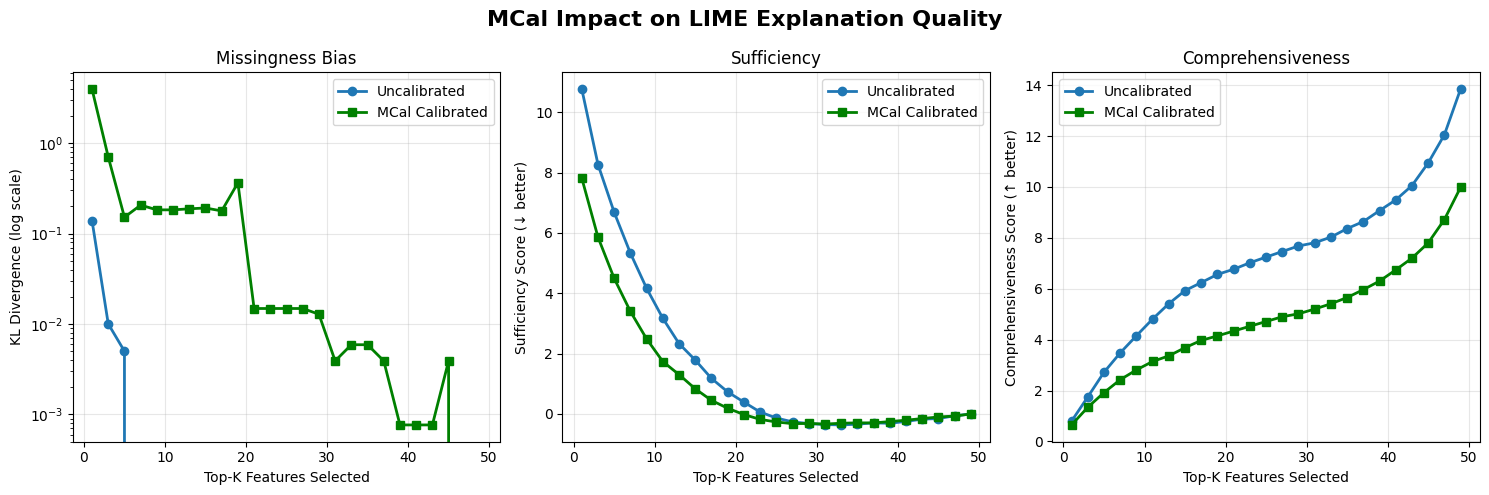

In [12]:
# Create plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

k_vals = config['k_values']

# Plot 1: Missingness Bias
axes[0].plot(k_vals, results['missingness_bias']['uncal'], 'o-', label='Uncalibrated', linewidth=2)
axes[0].plot(k_vals, results['missingness_bias']['calib'], 's-', label='MCal Calibrated', color='green', linewidth=2)
axes[0].set_xlabel('Top-K Features Selected')
axes[0].set_ylabel('KL Divergence (log scale)')
axes[0].set_title('Missingness Bias')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Plot 2: Sufficiency
axes[1].plot(k_vals, results['sufficiency']['uncal'], 'o-', label='Uncalibrated', linewidth=2)
axes[1].plot(k_vals, results['sufficiency']['calib'], 's-', label='MCal Calibrated', color='green', linewidth=2)
axes[1].set_xlabel('Top-K Features Selected')
axes[1].set_ylabel('Sufficiency Score (↓ better)')
axes[1].set_title('Sufficiency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Comprehensiveness
axes[2].plot(k_vals, results['comprehensiveness']['uncal'], 'o-', label='Uncalibrated', linewidth=2)
axes[2].plot(k_vals, results['comprehensiveness']['calib'], 's-', label='MCal Calibrated', color='green', linewidth=2)
axes[2].set_xlabel('Top-K Features Selected')
axes[2].set_ylabel('Comprehensiveness Score (↑ better)')
axes[2].set_title('Comprehensiveness')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('MCal Impact on LIME Explanation Quality', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Summary Statistics

In [13]:
# Compute average improvements
avg_kl_improve = np.mean([
    compute_metric_improvement(u, c, 'kl_divergence')
    for u, c in zip(results['missingness_bias']['uncal'], results['missingness_bias']['calib'])
])

avg_suff_improve = np.mean([
    compute_metric_improvement(u, c, 'sufficiency')
    for u, c in zip(results['sufficiency']['uncal'], results['sufficiency']['calib'])
])

avg_comp_improve = np.mean([
    compute_metric_improvement(u, c, 'comprehensiveness')
    for u, c in zip(results['comprehensiveness']['uncal'], results['comprehensiveness']['calib'])
])

print("="*60)
print("SUMMARY: MCal Improvement on LIME Explanations")
print("="*60)
print(f"\nAverage Improvements Across All K Values:")
print(f"  Missingness Bias (KL): {avg_kl_improve:+.1f}%")
print(f"  Sufficiency: {avg_suff_improve:+.1f}%")
print(f"  Comprehensiveness: {avg_comp_improve:+.1f}%")

SUMMARY: MCal Improvement on LIME Explanations

Average Improvements Across All K Values:
  Missingness Bias (KL): -503.8%
  Sufficiency: +36.0%
  Comprehensiveness: -31.8%


In [16]:
preds = torch.tensor([0, 1, 2, 0, 3, 2, 1, 0, 1, 1, 1, 1, 1])

In [17]:
torch.bincount(preds)

tensor([3, 7, 2, 1])